In [1]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.nn.functional import interpolate

from datasets import load_dataset
from inpaintingStart import *
import argparse

from PIL import Image
import gradio as gr
from imagenet_en_cn import IMAGENET_1K_CLASSES
from omegaconf import OmegaConf

import torch
from transformers import T5EncoderModel, AutoTokenizer

from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.pipeline_pixelflow import PixelFlowPipeline
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

from sampler2 import PixelFlowPipeline3
import time
import matplotlib.pyplot as plt
import imageio
import math
import copy
from pathlib import Path
from einops import rearrange
# ds = load_dataset("ILSVRC/imagenet-1k")

/home/ruy45/anaconda3/envs/pixelflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_dir = '/home/../mnt/data3/ruy45/dataset/imageNet256/ILSVRC/Data/CLS-LOC/train/'

def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])
dataset = ImageFolder(data_dir, transform=transform)

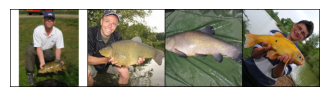

In [3]:
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)
imgs, labels = next(iter(loader))      # imgs: [B,3,256,256] in [-1,1]
imgs_vis = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(imgs_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [4]:
seed_everything(20000120)
num_stages = 4 # config.scheduler.num_stages
resolution = 256
NUM_EXAMPLES = 8
sigma_n = 0.05
class_label = 10
shift = 1.0
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
output_dir = './pretrained_models/c2img'
box_operator = get_operator("inpainting", mask_type='box', mask_len_range=(80, 160), mask_prob_range=None, resolution=resolution, device=device, sigma=sigma_n)
random_operator = inpainting_operator = get_operator("inpainting", mask_type='random', mask_prob_range=(0.15, 0.2), resolution=resolution, device=device, sigma=sigma_n)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
config = OmegaConf.load(f"{output_dir}/config.yaml")
model = config_utils.instantiate_from_config(config.model).to(device)
print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
ckpt = torch.load(f"{output_dir}/model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()
text_encoder = None
tokenizer = None
scheduler = PixelFlowScheduler(config.scheduler.num_train_timesteps, num_stages=config.scheduler.num_stages, gamma=-1/3)
scheduler_copy = copy.deepcopy(scheduler)
sampler_pipeline = PixelFlowPipeline3(scheduler_copy,model,text_encoder=text_encoder,tokenizer=tokenizer, max_token_length=512,)


Starting Initialization...
Num of parameters: 676611120


In [5]:
if class_label:
    # target_class_name = 'n01440764'   # If class label available
    # class_label = dataset.class_to_idx[target_class_name]
    class_indices = [i for i, (_, y) in enumerate(dataset.samples) if y == class_label]
    perm = torch.randperm(len(class_indices))[:NUM_EXAMPLES]
    selected_indices = [class_indices[i] for i in perm]
    gt = torch.stack([dataset[i][0] for i in selected_indices], dim=0)
    labels = [dataset[i][1] for i in selected_indices]
else:
    idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
    gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
    labels = [dataset[i][1] for i in idx]

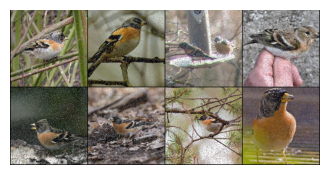

In [6]:
sigma_n =0.05
A_opr = random_operator
y = A_opr.measure(gt)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

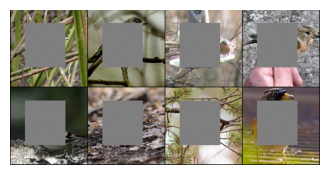

In [7]:
sigma_n =0.05
A_opr = box_operator
y = A_opr.measure(gt)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
def sample_block_noise(scheduler, bs, ch, height, width, eps=1e-6):
    gamma = scheduler.gamma
    dist = torch.distributions.multivariate_normal.MultivariateNormal(torch.zeros(4), torch.eye(4) * (1 - gamma) + torch.ones(4, 4) * gamma + eps * torch.eye(4))
    block_number = bs * ch * (height // 2) * (width // 2)
    noise = torch.stack([dist.sample() for _ in range(block_number)]) # [block number, 4]
    noise = rearrange(noise, '(b c h w) (p q) -> b c (h p) (w q)',b=bs,c=ch,h=height//2,w=width//2,p=2,q=2)
    return noise
def T_to_t_linear(Timesteps, t, T):
    '''
    provide global T to get local t at the stage.
    '''
    T_end = Timesteps[-1]
    T_start = Timesteps[0]
    t_end = t[-2]
    t_start = t[0]
    k = (T_end - T_start) / (t_end - t_start)
    b = T_start - t_start * k
    return (T-b)/k
def get_xt_from_x1(scheduler, Timesteps, x1, stage_idx, T, noise = None):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    resolution = x1.shape[-1]
    pixel_values_end = x1
    pixel_values_start = x1
    if stage_idx < num_stages - 1:
        # pixel_values_end
        for downsample_idx in range(1, num_stages - stage_idx):
            pixel_values_end = F.interpolate(pixel_values_end, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")

        # pixel_values_start
    
    for downsample_idx in range(1, num_stages - stage_idx + 1):
        pixel_values_start = F.interpolate(pixel_values_start, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")
    # upsample pixel_values_start
    end_height, end_width = pixel_values_end.shape[-1], pixel_values_end.shape[-2]
    pixel_values_start = F.interpolate(pixel_values_start, (end_height, end_width), mode="nearest")
    if noise == None:
        noise = torch.randn_like(pixel_values_end)
    pixel_values_end = end_t * pixel_values_end + (1.0 - end_t) * noise
    # print(pixel_values_end.shape, pixel_values_start.shape, noise.shape)
    pixel_values_start = start_t * pixel_values_start + (1.0 - start_t) * noise

    # Ts = scheduler.Timesteps_per_stage[stage_idx].to(torch.float64)
    # k = int(torch.argmin(torch.abs(Ts - T)).item())              # nearest index
    # t_select = torch.tensor(scheduler.t_window_per_stage[stage_idx][k].item(), dtype = torch.float32, device = device) 
    t_select = T_to_t_linear(Timesteps, scheduler.t, T).to(device)
    xt = t_select.float() * pixel_values_end.to(device) + (1.0 - t_select.float()) * pixel_values_start.to(device)
    # print(start_t, end_t, T, t_select)
    return xt
def get_xt_from_x1_sameStage(scheduler, Timesteps, D_x1, stage_idx, step_idx, DU_x0 = None, noise = None):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    if noise == None:
        noise = torch.randn_like(D_x1)
    pixel_values_end = end_t * D_x1 + (1.0 - end_t) * noise
    if DU_x0 == None:
        pixel_values_start = start_t * DownUp_operation(D_x1) + (1.0 - start_t) * noise
    else:
        pixel_values_start = DU_x0
    xt = scheduler.t[step_idx].float() * pixel_values_end.to(device) + (1.0 - scheduler.t[step_idx].float()) * pixel_values_start.to(device)
    return xt

In [9]:
scheduler_copy.set_timesteps(10, 3, device=device, shift=shift)
Timesteps3 = scheduler_copy.Timesteps

In [10]:
Timesteps3, scheduler_copy.start_t, scheduler_copy.end_t, 

(tensor([719.0000, 750.1111, 781.2222, 812.3333, 843.4444, 874.5556, 905.6667,
         936.7778, 967.8889, 999.0000], device='cuda:1', dtype=torch.float64),
 {0: 0.0,
  1: 0.14285714285714285,
  2: 0.3333333333333333,
  3: 0.6000000000000001},
 {0: 0.25, 1: 0.5, 2: 0.75, 3: 1.0})

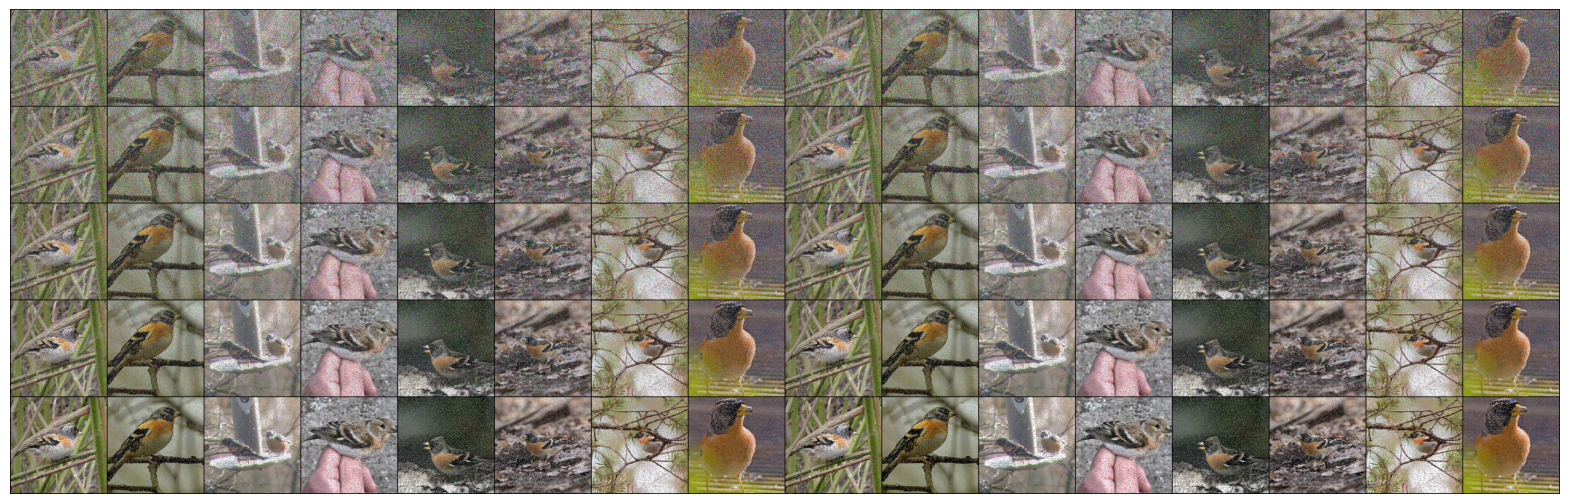

In [11]:
xts = []
ys = []
for T in Timesteps3:
    xt = get_xt_from_x1(scheduler_copy, Timesteps3, gt, 3, T)
    xts.append(xt)
    yt = get_xt_from_x1(scheduler_copy, Timesteps3, random_operator(gt), 3, T)
    ys.append(yt)
ys = torch.concat(ys, dim = 0)
xts = torch.concat(xts, dim = 0)

y_vis = (ys.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=16)     # [3,H,W]
plt.figure(figsize=(20, 32))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()


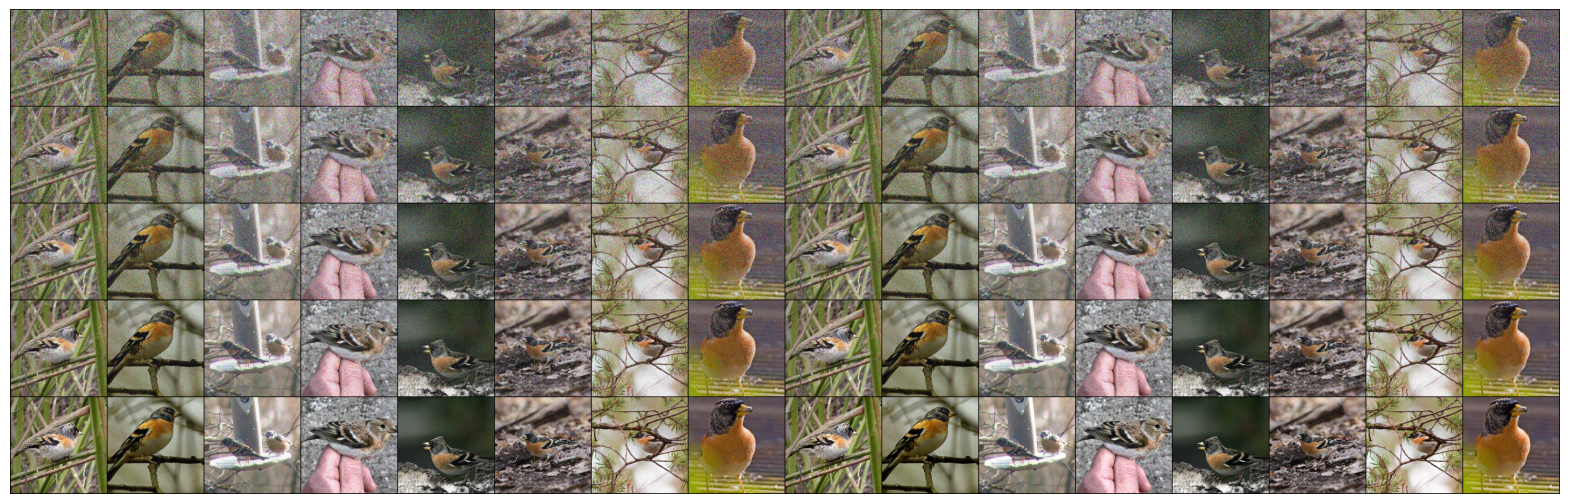

In [12]:
y_vis = (xts.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=16)     # [3,H,W]
plt.figure(figsize=(20, 32))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()


In [13]:
def Up_k(x, y):
    target_hw = y.shape[-2:]
    target_h, target_w = target_hw
    if x.shape[-2:] == target_hw:
        return x
    else:
        h, w = x.shape[-2:]

        out = x
        while h < target_h or w < target_w:
            next_h = min(h * 2, target_h)
            next_w = min(w * 2, target_w)

            out = F.interpolate(
                out,
                size=(next_h, next_w),
                mode="bilinear",
            )
            h, w = next_h, next_w

        if (h, w) != (target_h, target_w):
            out = F.interpolate(
                out,
                size=(target_h, target_w),
                mode="bilinear",
            )
        return out

def DownUp_operation(z, scale_factor=2):
    B, C, H, W = z.shape
    h_small = H // scale_factor
    w_small = W // scale_factor

    z_down = F.interpolate(
        z, size=(h_small, w_small),
        mode="bilinear",
    )
    z_up = F.interpolate(
        z_down, size=(H, W),
        mode='nearest',
    )
    return z_up

In [14]:
def objective_split_prior(x0hat, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M):
    # Match data end
    stage_x_end = stage_x_end.requires_grad_(False)
    stage_x_start = stage_x_start.requires_grad_(False)
    # x_up_proj = (1-o_M)*operator(Up_k(x0hat, y)) + o_M*y
    x_up_proj = operator(Up_k(x0hat, y))
    l3 = (1/(2*sigma_n**2)*(x_up_proj- y)**2).mean()

    # Optional smooth regularization on x0hat.
    # if self.split_prior_smooth_weight > 0:
    #     dx = x0hat[:, :, 1:, :] - x0hat[:, :, :-1, :]
    #     dy = x0hat[:, :, :, 1:] - x0hat[:, :, :, :-1]
    #     l_smooth = self.split_prior_smooth_weight * (dx.pow(2).mean() + dy.pow(2).mean())
    # else:
    #     l_smooth = x0hat.new_tensor(0.0)
    # return l3
    var_eps = 1e-5 # in case of 0 as a denominator
    denom_end = max(float((1 - stage_t_end) ** 2), var_eps)
    denom_start = max(float((1 - stage_t_start) ** 2), var_eps)
    l1 = (1 / (2 * denom_end) * (stage_x_end - stage_t_end * x0hat) ** 2).mean()
    l2 = (1 / (2 * denom_start) * (stage_x_start - stage_t_start * DownUp_operation(x0hat)) ** 2).mean()
    return l1 + l2 + l3, l1, l2, l3

    # return l1 + l2 + l3 + l_smooth

In [15]:
def objective_split_prior(x0hat, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M):
    # Match data end
    stage_x_end = stage_x_end.requires_grad_(False)
    stage_x_start = stage_x_start.requires_grad_(False)
    # x_up_proj = (1-o_M)*operator(Up_k(x0hat, y)) + o_M*y
    x_up_proj = operator(Up_k(x0hat, y))
    l3 = (1/(2*sigma_n**2)*(x_up_proj- y)**2).mean()

    # Optional smooth regularization on x0hat.
    # if self.split_prior_smooth_weight > 0:
    #     dx = x0hat[:, :, 1:, :] - x0hat[:, :, :-1, :]
    #     dy = x0hat[:, :, :, 1:] - x0hat[:, :, :, :-1]
    #     l_smooth = self.split_prior_smooth_weight * (dx.pow(2).mean() + dy.pow(2).mean())
    # else:
    #     l_smooth = x0hat.new_tensor(0.0)
    # return l3
    var_eps = 1e-5 # in case of 0 as a denominator
    denom_end = max(float((1 - stage_t_end) ** 2), var_eps)
    denom_start = max(float((1 - stage_t_start) ** 2), var_eps)
    l1 = (1 / (2 * denom_end) * (stage_x_end - stage_t_end * x0hat) ** 2).mean()
    l2 = (1 / (2 * denom_start) * (stage_x_start - stage_t_start * DownUp_operation(x0hat)) ** 2).mean()
    return l1 + l2 + l3, l1, l2, l3

    # return l1 + l2 + l3 + l_smooth

In [16]:
@torch.no_grad()
def langevin_update_split_prior(
    x: torch.Tensor,
    y: torch.Tensor,
    operator,
    stage_t_end, 
    stage_t_start, 
    stage_x_end: torch.Tensor,
    stage_x_start: torch.Tensor,
    sigma_n: float,                   
    step_size: float, 
    o_M,
    device,
):
    x = x.to(device)
    y = y.to(device)
    """
    One step overdamped Langevin for p(x) ∝ exp(-L(x)).
    L(x) = 1/(2σ_n^2)||Hx-y||^2 + 1/(2ν_t^2)||x-x1hat||^2
    """
    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        # loss = objective_split_prior(x, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M)
        loss, l1,l2,l3 = objective_split_prior(x, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M)
        grad = torch.autograd.grad(loss, x)[0]
    grad_norm = grad.norm().item()
    delta_norm = (step_size * grad).norm().item()
    # grad = torch.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0)
    # if self.langevin_grad_clip is not None:
    #     grad_norm = grad.norm().clamp_min(1e-12)
    #     clip_val = grad.new_tensor(self.langevin_grad_clip)
    #     grad = grad * torch.clamp(clip_val / grad_norm, max=1.0)
    x_new = x - step_size*grad + math.sqrt(2.0 * step_size)*torch.randn_like(x)
    # x_new = x - step_size*grad 
    # x_new = torch.nan_to_num(x_new, nan=0.0, posinf=1e6, neginf=-1e6)
    # if langevin_x_clamp is not None:
    #     x_new = torch.clamp(x_new, -langevin_x_clamp, langevin_x_clamp)
    return x_new, {
        "loss": f"{float(loss.detach().cpu()):.5f}",
        "l1": f"{float(l1.detach().cpu()):.5f}",
        "l2": f"{float(l2.detach().cpu()):.5f}",
        "l3": f"{float(l3.detach().cpu()):.5f}",
        "grad_norm": f"{grad_norm:.5f}",
        "delta_norm": f"{delta_norm:.5f}",
        "z_mean": f"{float(x_new.mean().detach().cpu()):.5f}",
        "z_std": f"{float(x_new.std().detach().cpu()):.5f}",
    }
def langevin_sample_split_prior(
    x_init, y, operator, stage_t_end,stage_t_start, stage_x_end, stage_x_start, num_Langevin,
    sigma_n, 
    step_size=1e-4,
    device = "cpu",
    proj = False,
    return_traj = False
):
    if proj:
        if hasattr(operator, "get_mask"):
            o_M = operator.get_mask(x=y).to(device)
        else:
            o_M = operator.mask.to(device)
    else:
        o_M = torch.zeros_like(y, device=device)
    x = x_init.clone().detach()
    for _ in range(num_Langevin):
        x,record = langevin_update_split_prior(x,y,operator, stage_t_end, stage_t_start, 
                                                stage_x_end, stage_x_start, sigma_n,  step_size, o_M, device)
        if return_traj:
            if _ % 10 == 0:
                print(record)
        # if torch.isnan(x).any():
        #     break
    return x.detach()

In [17]:
def plot(latents, nrow, save_name =None):
    if isinstance(latents, list):
        latents = torch.concat(latents, dim = 0)
    y_vis = (latents.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
    grid = make_grid(y_vis, nrow=nrow)     # [3,H,W]
    plt.figure(figsize=(5*nrow/4, 8*nrow/4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    if save_name != None:
        plt.savefig(f"{save_name}.png", bbox_inches="tight", pad_inches=0)
    plt.show()

In [18]:
Timesteps3, scheduler_copy.start_t, scheduler_copy.end_t

(tensor([719.0000, 750.1111, 781.2222, 812.3333, 843.4444, 874.5556, 905.6667,
         936.7778, 967.8889, 999.0000], device='cuda:1', dtype=torch.float64),
 {0: 0.0,
  1: 0.14285714285714285,
  2: 0.3333333333333333,
  3: 0.6000000000000001},
 {0: 0.25, 1: 0.5, 2: 0.75, 3: 1.0})

# Get baseline at stage 3 (Random operator processed)
### Save stage_start_t; stage_end_t, xt

In [251]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
stage_idx = 3
inference_each_step = 10
start_T_idx = 0
guidance_scale = 0
resolution = 256
num_Langevin = 100
shift = 1.0
proj = False

xt_starts = []
xt_ends = []
xt_each_steps = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
Timesteps_k = scheduler_copy.Timesteps
start_t = scheduler_copy.start_t[stage_idx]
end_t = scheduler_copy.end_t[stage_idx]

xt = get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx])
latents = get_xt_from_x1(scheduler_copy, Timesteps_k, random_operator(gt), stage_idx, Timesteps_k[start_T_idx])
do_classifier_free_guidance = True if guidance_scale > 0 else 0


size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
pos_embed = get_2d_rotary_pos_embed(
    embed_dim=model.attention_head_dim,
    crops_coords=(
        (0, 0),
        (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    ),
    grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    device=device,
    output_type="pt",)
rope_pos = torch.stack(pos_embed, -1)
with torch.no_grad():
    for T in Timesteps_k[start_T_idx:]:
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
        noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                            latent_size=size_tensor, pos_embed=rope_pos)

        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
        
        t_curr = scheduler_copy.t[start_T_idx].to(device=latents.device, dtype=latents.dtype)
        t_next = scheduler_copy.t[start_T_idx +1].to(device=latents.device, dtype=latents.dtype)


        latents = latents + (t_next - t_curr) * noise_pred

        pixel_values_start = latents - t_curr * noise_pred
        pixel_values_end = latents + (1.0 - t_curr) * noise_pred
        start_T_idx+=1

        xt_starts.append(pixel_values_start)
        xt_ends.append(pixel_values_end)
        xt_each_steps.append(latents)

        

In [173]:
# plot(xt_starts, 8, save_name = "./outputs/stepbystepCheck/pred_stage_start")
# plot(xt_ends, 8, save_name = "./outputs/stepbystepCheck/pred_stage_end")
# plot(xt_each_steps, 8, save_name = "./outputs/stepbystepCheck/pred_xt")

# Test one-step velocity prediction


In [19]:
def pred_x1_x0_with_vt(xt, vt, T, start_t, end_t):
    x1_normal = xt + (1-T/1000)/(end_t - start_t)*vt
    x0_normal = xt - T/1000*(end_t - start_t)*vt
    return x1_normal, x0_normal

In [111]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed

device = torch.device("cuda:0")
model = model.to(device)
stage_idx = 3
inference_each_step = 10
start_T_idx = 0
guidance_scale = 0
resolution = 256
num_Langevin = 100


x1_normal_process = []
x0_normal_process = []
xt_each_step_normal_process = []

x1_end_and_back = []
x0_start_and_back = []

prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
Timesteps_k = scheduler_copy.Timesteps
start_t = scheduler_copy.start_t[stage_idx]
end_t = scheduler_copy.end_t[stage_idx]

xt = get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx])
latents = get_xt_from_x1(scheduler_copy, Timesteps_k, random_operator(gt), stage_idx, Timesteps_k[start_T_idx])
do_classifier_free_guidance = True if guidance_scale > 0 else 0


size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
pos_embed = get_2d_rotary_pos_embed(
    embed_dim=model.attention_head_dim,
    crops_coords=(
        (0, 0),
        (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    ),
    grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    device=device,
    output_type="pt",)
rope_pos = torch.stack(pos_embed, -1)
with torch.no_grad():
    for T in Timesteps_k[start_T_idx:]:
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
        noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                            latent_size=size_tensor, pos_embed=rope_pos)

        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
        t_curr = scheduler_copy.t[start_T_idx].to(device=latents.device, dtype=latents.dtype)
        t_next = scheduler_copy.t[start_T_idx +1].to(device=latents.device, dtype=latents.dtype)

        # Forward and Backward
        x1, x0 = pred_x1_x0_with_vt(latents, noise_pred, T, start_t, end_t)
        DU_x1 = latents - t_curr * noise_pred
        if start_T_idx + 1 == inference_each_step:
            T_curr = Timesteps_k[start_T_idx]
            interpolated_noise = math.sqrt(1 - T_curr/1000) * torch.randn_like(latents) + math.sqrt(T_curr/1000) * x0
        else: 
            T_next = Timesteps_k[start_T_idx + 1]
            interpolated_noise = math.sqrt(1 - T_next/1000) * torch.randn_like(latents) + math.sqrt(T_next/1000) * x0
        latents = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1, stage_idx, start_T_idx+1, DU_x0=None, noise=interpolated_noise)
        print(x1.mean(), x0.mean(), latents.mean(), 
              x1.std(), x0.std(), latents.std())
        x1_end_and_back.append(x1)
        x0_start_and_back.append(x0)
        xt_each_step_normal_process.append(latents)


        # # Normal inference traj


        # x1_normal = latents + (1-T/1000)/(end_t - start_t)*noise_pred
        # x0_normal = latents - T/1000*(end_t - start_t)*noise_pred
        # # normal process
        # latents = latents + (t_next - t_curr) * noise_pred

        # x1_normal_process.append(x1_normal)
        # x0_normal_process.append(x0_normal)
        # xt_each_step_normal_process.append(latents)
        # print(x1_normal.mean(), x0_normal.mean(), latents.mean(), 
        #       x1_normal.std(), x0_normal.std(), latents.std())
        start_T_idx += 1

tensor(-0.0735, device='cuda:0') tensor(-0.0405, device='cuda:0') tensor(-0.0599, device='cuda:0') tensor(0.3548, device='cuda:0') tensor(0.5482, device='cuda:0') tensor(0.3778, device='cuda:0')
tensor(-0.0827, device='cuda:0') tensor(-0.0490, device='cuda:0') tensor(-0.0705, device='cuda:0') tensor(0.3781, device='cuda:0') tensor(0.4223, device='cuda:0') tensor(0.3705, device='cuda:0')
tensor(-0.0924, device='cuda:0') tensor(-0.0580, device='cuda:0') tensor(-0.0817, device='cuda:0') tensor(0.4142, device='cuda:0') tensor(0.3827, device='cuda:0') tensor(0.3919, device='cuda:0')
tensor(-0.1021, device='cuda:0') tensor(-0.0675, device='cuda:0') tensor(-0.0932, device='cuda:0') tensor(0.4511, device='cuda:0') tensor(0.3798, device='cuda:0') tensor(0.4251, device='cuda:0')
tensor(-0.1113, device='cuda:0') tensor(-0.0775, device='cuda:0') tensor(-0.1044, device='cuda:0') tensor(0.4865, device='cuda:0') tensor(0.3938, device='cuda:0') tensor(0.4626, device='cuda:0')
tensor(-0.1197, device='c

In [113]:
# plot(x1_end_and_back, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_x1_fw&back_traj_{stage_idx}_Intpnoise")
# plot(x0_start_and_back, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_x0_fw&back_traj_{stage_idx}_Intpnoise")
# plot(xt_each_step_normal_process, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_xt_fw&back_traj_{stage_idx}_Intpnoise")

In [47]:
# plot(x1_normal_process, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_x1_inference_traj_{stage_idx}")
# plot(x0_normal_process, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_x0_inference_traj_{stage_idx}")
# plot(xt_each_step_normal_process, 8, save_name = f"./outputs/stepbystepCheck/test_one_v_step/pred_xt_inference_traj_{stage_idx}")

# Test predict stage start and stage end

In [171]:
sum(scheduler.start_t.values()), sum(scheduler.end_t.values()), 0.25/(sum(scheduler.start_t.values()) - sum(scheduler.end_t.values()))

(1.0761904761904764, 2.5, -0.17558528428093648)

In [20]:
def get_global_stage_window(stage_idx):
    start_t = scheduler.start_t[stage_idx]
    end_t = scheduler.end_t[stage_idx]
    d = [scheduler.end_t[i] - scheduler.start_t[i] for i in range(scheduler.num_stages)]
    D = sum(d)

    global_start = sum(d[:stage_idx]) / D
    global_end   = sum(d[:stage_idx + 1]) / D
    return global_start, global_end
get_global_stage_window(3)

(0.7190635451505017, 1.0)

In [21]:
def get_x1_and_noise_with_stage_start_and_end(xe, xs, scheduler, stage_idx):
    '''
    xs: x stage start
    xe: x stage end
    stage_idx: 0-3, 3: original resolution
    return: x1: data, x0: noise
    Note: x1 and x0 are predicted version, we use x1 only as an initial, x0 will not be used. However, since xe and xs are predicted data, 
        e-s will enlarge the error.
    '''
    def get_global_stage_window(stage_idx):
        start_t = scheduler.start_t[stage_idx]
        end_t = scheduler.end_t[stage_idx]
        d = [scheduler.end_t[i] - scheduler.start_t[i] for i in range(scheduler.num_stages)]
        D = sum(d)

        global_start = sum(d[:stage_idx]) / D
        global_end   = sum(d[:stage_idx + 1]) / D
        return global_start, global_end
    s, e = get_global_stage_window(stage_idx)
    x1 = ((1 - s)*xe - (1 - e)*xs)/ (e - s)
    x0 = (e*xs -s*xe)/(e-s)
    return x1, x0, e, s
    # Tested, x1 looks good but x0 looks a little bit strange but it's not used.
def get_x1_and_noise_with_stage_start_and_end2(xe, xs, scheduler, stage_idx):
    '''
    follow the training t
    '''
    s, e = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    x1 = ((1 - s)*xe - (1 - e)*xs)/ (e - s)
    x0 = (e*xs -s*xe)/(e-s)
    return x1, x0, e, s
    # Tested, x1 looks good but x0 looks a little bit strange but it's not used.



def get_lr(ratio):
    p = langevin_step_p = 1 # set it fixed for now
    lr_min_ratio = langevin_step_min_ratio = 1e-2 # set it fixed for now
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    return multiplier * 1e-4 # set the lr base

In [ ]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
stage_idx = 3
inference_each_step = 10
start_T_idx = 0
guidance_scale = 0
resolution = 256
num_Langevin = 100
proj = False

x0_pred = []
x1_pred = []
xt_each_steps = []
beforeLangiven = []
afterLangevin = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
Timesteps_k = scheduler_copy.Timesteps
start_t = scheduler_copy.start_t[stage_idx]
end_t = scheduler_copy.end_t[stage_idx]

xt = get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx])
y = random_operator.measure(gt)
latents = get_xt_from_x1(scheduler_copy, Timesteps_k, y, stage_idx, Timesteps_k[start_T_idx])

do_classifier_free_guidance = True if guidance_scale > 0 else 0


size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
pos_embed = get_2d_rotary_pos_embed(
    embed_dim=model.attention_head_dim,
    crops_coords=(
        (0, 0),
        (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    ),
    grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
    device=device,
    output_type="pt",)
rope_pos = torch.stack(pos_embed, -1)
with torch.no_grad():
    for T in Timesteps_k[start_T_idx:]:
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
        noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                            latent_size=size_tensor, pos_embed=rope_pos)

        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
        
        t_curr = scheduler_copy.t[start_T_idx].to(device=latents.device, dtype=latents.dtype)
        t_next = scheduler_copy.t[start_T_idx +1].to(device=latents.device, dtype=latents.dtype)


        latents = latents + (t_next - t_curr) * noise_pred

        pixel_values_start = latents - t_curr * noise_pred
        pixel_values_end = latents + (1.0 - t_curr) * noise_pred
        

        x1, x0, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end, pixel_values_start, scheduler_copy, stage_idx)
        ratio = float(T.detach().item()) / 1000.0 if torch.is_tensor(T) else float(T) / 1000.0
        lr = float(get_lr(ratio))
        samples_after_langevin = langevin_sample_split_prior(x1.clone().detach(), y, random_operator, e, s, pixel_values_end.clone().detach(), 
                                                             pixel_values_start.clone().detach(), num_Langevin, sigma_n, lr, device, 
                                                             proj = False, return_traj=True)
        # Now move to the next state
        start_T_idx+=1
        if stage_idx ==3 and start_T_idx == inference_each_step:
            pass
        else:
            # scheme 1: do it one more time as the training goes to get xt with x1
            # scheme 2: get xe and sample between xs and xe; not tried yet but xs and xe are not as consistent as scheme 1.
            # scheme 3: For both schemes, noise can also be randn or interpolate btw x0 and randn.
            latents = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, samples_after_langevin, stage_idx, start_T_idx, noise = None, DU_x0 = None)
            # latents = get_xt_from_x1(scheduler_copy, Timesteps_k, x1, stage_idx, T, noise = None)
        
        xt_each_steps.append(latents.clone())
        beforeLangiven.append(x1)
        afterLangevin.append(samples_after_langevin)
        x0_pred.append(x0)
        x1_pred.append(x1)
        # xt_each_steps.append(latents)

{'loss': '4.02077', 'l1': '0.00000', 'l2': '0.40415', 'l3': '3.61662', 'grad_norm': '0.04250', 'delta_norm': '0.00000', 'z_mean': '-0.08697', 'z_std': '0.39330'}
{'loss': '32.94329', 'l1': '28.82548', 'l2': '0.40432', 'l3': '3.71350', 'grad_norm': '1.92145', 'delta_norm': '0.00006', 'z_mean': '-0.08696', 'z_std': '0.39401'}
{'loss': '61.84959', 'l1': '57.63712', 'l2': '0.40446', 'l3': '3.80801', 'grad_norm': '2.71663', 'delta_norm': '0.00008', 'z_mean': '-0.08697', 'z_std': '0.39479'}
{'loss': '90.73922', 'l1': '86.42889', 'l2': '0.40464', 'l3': '3.90569', 'grad_norm': '3.32656', 'delta_norm': '0.00010', 'z_mean': '-0.08696', 'z_std': '0.39550'}
{'loss': '119.65617', 'l1': '115.24742', 'l2': '0.40479', 'l3': '4.00395', 'grad_norm': '3.84128', 'delta_norm': '0.00011', 'z_mean': '-0.08697', 'z_std': '0.39624'}
{'loss': '148.52142', 'l1': '144.01364', 'l2': '0.40497', 'l3': '4.10282', 'grad_norm': '4.29399', 'delta_norm': '0.00012', 'z_mean': '-0.08696', 'z_std': '0.39699'}
{'loss': '177.

In [28]:
# plot(xt_each_steps, 8, save_name = "./outputs/stepbystepCheck/measurementMatchingOnly/xt")
# plot(beforeLangiven, 8, save_name = "./outputs/stepbystepCheck/measurementMatchingOnly/before_langevin_x1")
# plot(afterLangevin, 8, save_name = "./outputs/stepbystepCheck/measurementMatchingOnly/afteLangevin_x1")

In [37]:
# plot(xt_each_steps, 8, save_name = "./outputs/stepbystepCheck/totalLoss/xt")
# plot(beforeLangiven, 8, save_name = "./outputs/stepbystepCheck/totalLoss/before_langevin_x1")
# plot(afterLangevin, 8, save_name = "./outputs/stepbystepCheck/totalLoss/afteLangevin_x1")

In [ ]:
# Check the difference with and wo .clone().detach() for pxiel_values_start; pxiel_values_end 

In [193]:
# xt = [get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx]) for start_T_idx in range(10)]
# latents = [get_xt_from_x1(scheduler_copy, Timesteps_k, random_operator(gt), stage_idx, Timesteps_k[start_T_idx]) for start_T_idx in range(10)]
# plot(xt, 8, save_name = "./outputs/stepbystepCheck/xt_gt")
# plot(latents, 8, save_name = "./outputs/stepbystepCheck/y_gt")

In [191]:
# plot(x0_pred, 8, save_name = "./outputs/stepbystepCheck/pred_x0_test_recover_func_train")
# plot(x1_pred, 8, save_name = "./outputs/stepbystepCheck/pred_x1_test_recover_func_train")
# plot(xt_each_steps, 8, save_name = "./outputs/stepbystepCheck/pred_xt_train")

# Now try to put it into multi-scale setting to see if it works or not

In [22]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
num_Langevin = 0
proj = False

x0_pred = []
x1_pred = []
xt_each_steps = []
beforeLangiven = []
afterLangevin = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

# scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
# Timesteps_k = scheduler_copy.Timesteps
# start_t = scheduler_copy.start_t[stage_idx]
# end_t = scheduler_copy.end_t[stage_idx]

# xt = get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx])
# y = random_operator.measure(gt)
# latents = get_xt_from_x1(scheduler_copy, Timesteps_k, y, stage_idx, Timesteps_k[start_T_idx])

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents = randn_tensor(shape, device=device, dtype=torch.float32)
with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents = F.interpolate(latents, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents.shape)
            noise = noise.to(device=device, dtype=latents.dtype)
            latents = alpha * latents + beta * noise

        size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            ),
            grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)
        print(stage_idx)

        for step_idx, T in enumerate(Timesteps_k):
            latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
            timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
            noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents.device, dtype=latents.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents.device, dtype=latents.dtype)


            latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start = latents - t_curr * noise_pred
            pixel_values_end = latents + (1.0 - t_curr) * noise_pred
            
            x1, x0, e, s = get_x1_and_noise_with_stage_start_and_end(pixel_values_end, pixel_values_start, scheduler_copy, stage_idx)
            ratio = float(T.detach().item()) / 1000.0 if torch.is_tensor(T) else float(T) / 1000.0
            lr = float(get_lr(ratio))
            samples_after_langevin = langevin_sample_split_prior(x1.clone().detach(), y, random_operator, e, s, pixel_values_end.clone().detach(), 
                                                                pixel_values_start.clone().detach(), num_Langevin, sigma_n, lr, device, 
                                                                proj = False, return_traj=True)

            # Now move to the next state
            if stage_idx ==3 and step_idx + 1 == inference_each_step:
                latents = samples_after_langevin.clone().detach() 
            else:
                # scheme 1: do it one more time as the training goes to get xt with x1
                # scheme 2: get xe and sample between xs and xe; not tried yet but xs and xe are not as consistent as scheme 1.
                # scheme 3: For both schemes, noise can also be randn or interpolate btw x0 and randn.
                latents = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, samples_after_langevin, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start)
            
            xt_each_steps.append(latents.clone())
            beforeLangiven.append(x1)
            afterLangevin.append(samples_after_langevin)
            x0_pred.append(x0)
            x1_pred.append(x1)
            # xt_each_steps.append(latents)

0
1
2
3


In [23]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter


# ===== 工具函数 =====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x

def normalize_for_display(img, assume_image_range=True):
    img = img.astype(np.float32)

    if assume_image_range:
        # 默认按 [-1, 1] -> [0, 1]
        img = img / 2.0 + 0.5
        return np.clip(img, 0, 1)
    else:
        # 给 xt / latent 用 min-max 更直观
        mn, mx = float(img.min()), float(img.max())
        if mx - mn < 1e-8:
            return np.zeros_like(img, dtype=np.float32)
        return np.clip((img - mn) / (mx - mn), 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


# ===== 你的输入变量 =====
traj_before = beforeLangiven      # Langevin 前 x1
traj_after  = afterLangevin       # Langevin 后 x1
traj_xt     = xt_each_steps       # 下一步 xt
traj_x0 = x0_pred
traj_x1 = x1_pred

traj_list = [traj_x0, traj_x1, traj_before, traj_after, traj_xt]
row_names = ["x0_pred","x1_pred", "Before Langevin", "After Langevin","xt", "GT"]

# 这里 gt 要是 [B,C,H,W]
gt_tensor = gt

# 选择显示哪些 batch 样本
plot_ids = [0, 1, 4, 7]   # 你可自己改


# ===== 构造每一帧对应的 T 和 stage =====
def build_T_and_stage_list_from_scheduler(scheduler_obj, num_stages, inference_each_step, shift, expected_len=None):
    T_list, stage_list, step_list = [], [], []

    for s in range(num_stages):
        scheduler_obj.set_timesteps(inference_each_step, s, device=device, shift=shift)
        Timesteps = scheduler_obj.Timesteps

        for k, T in enumerate(Timesteps):
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))
            step_list.append(int(k))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L], step_list[:L]
    return T_list, stage_list, step_list


# 注意：traj_xt 有可能比 before/after 少 1 帧，所以按最短长度截断
raw_min_len = min(len(traj_before), len(traj_after), len(traj_xt))
T_list, stage_list, step_list = build_T_and_stage_list_from_scheduler(
    scheduler_copy,
    num_stages,
    inference_each_step,
    shift,
    expected_len=raw_min_len,
)

min_len = min(raw_min_len, len(T_list), len(stage_list), len(step_list))
traj_list = [traj[:min_len] for traj in traj_list]
T_list = T_list[:min_len]
stage_list = stage_list[:min_len]
step_list = step_list[:min_len]


# ===== 显示策略 =====
x0_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
x1_assume_image_range  = True
before_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
after_assume_image_range  = True
xt_assume_image_range     = True  # xt 更像 latent / noisy state，建议 min-max

row_display_flags = [
    x0_assume_image_range,
    x1_assume_image_range,
    before_assume_image_range,
    after_assume_image_range,
    xt_assume_image_range,
]

# ===== 输出路径 =====
save_dir = "./outputs/stepbystepCheck/MS/"
os.makedirs(save_dir, exist_ok=True)

mp4_path = os.path.join(
    save_dir,
    f"langevin_stagewise_vis_steps{inference_each_step}_L{num_Langevin}0.mp4"
)
fps = 6


# ===== GT 预处理 =====
gt_imgs  = [to_display_image(gt_tensor, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im, assume_image_range=True) for im in gt_imgs]


# ===== 画图布局 =====
ncols = len(plot_ids)
nrows = 6

fig_w = 4.2 * ncols
fig_h = 9.5 * 1.5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

if ncols == 1:
    axes = axes.reshape(nrows, 1)

plt.subplots_adjust(wspace=0.02, hspace=0.08, top=0.92)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        stage_val = stage_list[i]
        step_val = step_list[i]

        fig.suptitle(
            f"Frame {i} | Stage = {stage_val} | Step = {step_val} | T = {T_str}",
            fontsize=12
        )

        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]
            target_disp = gt_disps[c]

            # ===== Row 0~5 =====
            for r in range(5):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)
                x_disp = normalize_for_display(x_img, assume_image_range=row_display_flags[r])

                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(
                        f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}",
                        fontsize=9
                    )
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row 5: GT =====
            ax = axes[5, c]
            ax.clear()

            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)

            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./outputs/stepbystepCheck/MS/langevin_stagewise_vis_steps10_L00.mp4


# Multi-scale with Langvevin one_step_v_predict

In [ ]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
num_Langevin = 0
proj = False

x0_pred = []
x1_pred = []
xt_each_steps = []
beforeLangiven = []
afterLangevin = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

# scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
# Timesteps_k = scheduler_copy.Timesteps
# start_t = scheduler_copy.start_t[stage_idx]
# end_t = scheduler_copy.end_t[stage_idx]

# xt = get_xt_from_x1(scheduler_copy, Timesteps_k, gt, stage_idx, Timesteps_k[start_T_idx])
# y = random_operator.measure(gt)
# latents = get_xt_from_x1(scheduler_copy, Timesteps_k, y, stage_idx, Timesteps_k[start_T_idx])

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents = randn_tensor(shape, device=device, dtype=torch.float32)
with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents = F.interpolate(latents, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents.shape)
            noise = noise.to(device=device, dtype=latents.dtype)
            latents = alpha * latents + beta * noise

        size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            ),
            grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)
        print(stage_idx)

        for step_idx, T in enumerate(Timesteps_k):
            latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
            timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
            noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents.device, dtype=latents.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents.device, dtype=latents.dtype)

            x1, x0 = pred_x1_x0_with_vt(latents, noise_pred, T, start_t, end_t)
            if step_idx + 1 == inference_each_step:
                T_curr = Timesteps_k[step_idx]
                interpolated_noise = math.sqrt(1 - T_curr/1000) * torch.randn_like(latents) + math.sqrt(T_curr/1000) * x0
            else: 
                T_next = Timesteps_k[step_idx + 1]
                interpolated_noise = math.sqrt(1 - T_next/1000) * torch.randn_like(latents) + math.sqrt(T_next/1000) * x0
            
            latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start = latents - t_curr * noise_pred
            pixel_values_end = latents + (1.0 - t_curr) * noise_pred

            
            x1_2, x0_2, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end, pixel_values_start, scheduler_copy, stage_idx)
            
            ratio = float(T.detach().item()) / 1000.0 if torch.is_tensor(T) else float(T) / 1000.0
            lr = float(get_lr(ratio))
            samples_after_langevin = langevin_sample_split_prior(x1.clone().detach(), y, random_operator, e, s, pixel_values_end.clone().detach(), 
                                                                pixel_values_start.clone().detach(), num_Langevin, sigma_n, lr, device, 
                                                                proj = False, return_traj=True)
            # Now move to the next state
            if stage_idx ==3 and step_idx + 1 == inference_each_step:
                latents = samples_after_langevin.clone().detach() 
            else:
                # scheme 1: do it one more time as the training goes to get xt with x1
                # scheme 2: get xe and sample between xs and xe; not tried yet but xs and xe are not as consistent as scheme 1.
                # scheme 3: For both schemes, noise can also be randn or interpolate btw x0 and randn.
                latents = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1, stage_idx, step_idx+1, DU_x0=pixel_values_start, noise=None)
                # latents = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, samples_after_langevin, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start)
            
            xt_each_steps.append(latents.clone())
            beforeLangiven.append(x1)
            afterLangevin.append(samples_after_langevin)
            x0_pred.append(x0)
            x1_pred.append(x1)
            # xt_each_steps.append(latents)

0
1
2
3


In [141]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter


# ===== 工具函数 =====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x

def normalize_for_display(img, assume_image_range=True):
    img = img.astype(np.float32)

    if assume_image_range:
        # 默认按 [-1, 1] -> [0, 1]
        img = img / 2.0 + 0.5
        return np.clip(img, 0, 1)
    else:
        # 给 xt / latent 用 min-max 更直观
        mn, mx = float(img.min()), float(img.max())
        if mx - mn < 1e-8:
            return np.zeros_like(img, dtype=np.float32)
        return np.clip((img - mn) / (mx - mn), 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


# ===== 你的输入变量 =====
traj_before = beforeLangiven      # Langevin 前 x1
traj_after  = afterLangevin       # Langevin 后 x1
traj_xt     = xt_each_steps       # 下一步 xt
traj_x0 = x0_pred
traj_x1 = x1_pred

traj_list = [traj_x0, traj_x1, traj_before, traj_after, traj_xt]
row_names = ["x0_pred","x1_pred", "Before Langevin", "After Langevin","xt", "GT"]

# 这里 gt 要是 [B,C,H,W]
gt_tensor = gt

# 选择显示哪些 batch 样本
plot_ids = [0, 1, 4, 7]   # 你可自己改


# ===== 构造每一帧对应的 T 和 stage =====
def build_T_and_stage_list_from_scheduler(scheduler_obj, num_stages, inference_each_step, shift, expected_len=None):
    T_list, stage_list, step_list = [], [], []

    for s in range(num_stages):
        scheduler_obj.set_timesteps(inference_each_step, s, device=device, shift=shift)
        Timesteps = scheduler_obj.Timesteps

        for k, T in enumerate(Timesteps):
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))
            step_list.append(int(k))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L], step_list[:L]
    return T_list, stage_list, step_list


# 注意：traj_xt 有可能比 before/after 少 1 帧，所以按最短长度截断
raw_min_len = min(len(traj_before), len(traj_after), len(traj_xt))
T_list, stage_list, step_list = build_T_and_stage_list_from_scheduler(
    scheduler_copy,
    num_stages,
    inference_each_step,
    shift,
    expected_len=raw_min_len,
)

min_len = min(raw_min_len, len(T_list), len(stage_list), len(step_list))
traj_list = [traj[:min_len] for traj in traj_list]
T_list = T_list[:min_len]
stage_list = stage_list[:min_len]
step_list = step_list[:min_len]


# ===== 显示策略 =====
x0_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
x1_assume_image_range  = True
before_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
after_assume_image_range  = True
xt_assume_image_range     = True  # xt 更像 latent / noisy state，建议 min-max

row_display_flags = [
    x0_assume_image_range,
    x1_assume_image_range,
    before_assume_image_range,
    after_assume_image_range,
    xt_assume_image_range,
]

# ===== 输出路径 =====
save_dir = "./outputs/stepbystepCheck/MS/vpredit/"
os.makedirs(save_dir, exist_ok=True)

mp4_path = os.path.join(
    save_dir,
    f"langevin_stagewise_vis_steps{inference_each_step}_L{num_Langevin}_DUx1.mp4"
)
fps = 6


# ===== GT 预处理 =====
gt_imgs  = [to_display_image(gt_tensor, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im, assume_image_range=True) for im in gt_imgs]


# ===== 画图布局 =====
ncols = len(plot_ids)
nrows = 6

fig_w = 4.2 * ncols
fig_h = 9.5 * 1.5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

if ncols == 1:
    axes = axes.reshape(nrows, 1)

plt.subplots_adjust(wspace=0.02, hspace=0.08, top=0.92)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        stage_val = stage_list[i]
        step_val = step_list[i]

        fig.suptitle(
            f"Frame {i} | Stage = {stage_val} | Step = {step_val} | T = {T_str}",
            fontsize=12
        )

        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]
            target_disp = gt_disps[c]

            # ===== Row 0~5 =====
            for r in range(5):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)
                x_disp = normalize_for_display(x_img, assume_image_range=row_display_flags[r])

                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(
                        f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}",
                        fontsize=9
                    )
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row 5: GT =====
            ax = axes[5, c]
            ax.clear()

            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)

            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./outputs/stepbystepCheck/MS/vpredit/langevin_stagewise_vis_steps10_L0_DUx1.mp4


In [20]:
for stage_idx in range(4):
    scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
    Timesteps_k = scheduler_copy.Timesteps[:]
    for step_idx, T in enumerate(Timesteps_k):
        print(stage_idx, step_idx, T, scheduler_copy.t[step_idx])

0 0 tensor(0., device='cuda:1', dtype=torch.float64) tensor(0., device='cuda:1', dtype=torch.float64)
0 1 tensor(19.4250, device='cuda:1', dtype=torch.float64) tensor(0.1110, device='cuda:1', dtype=torch.float64)
0 2 tensor(38.8500, device='cuda:1', dtype=torch.float64) tensor(0.2220, device='cuda:1', dtype=torch.float64)
0 3 tensor(58.2750, device='cuda:1', dtype=torch.float64) tensor(0.3330, device='cuda:1', dtype=torch.float64)
0 4 tensor(77.7000, device='cuda:1', dtype=torch.float64) tensor(0.4440, device='cuda:1', dtype=torch.float64)
0 5 tensor(97.1250, device='cuda:1', dtype=torch.float64) tensor(0.5550, device='cuda:1', dtype=torch.float64)
0 6 tensor(116.5500, device='cuda:1', dtype=torch.float64) tensor(0.6660, device='cuda:1', dtype=torch.float64)
0 7 tensor(135.9750, device='cuda:1', dtype=torch.float64) tensor(0.7770, device='cuda:1', dtype=torch.float64)
0 8 tensor(155.4000, device='cuda:1', dtype=torch.float64) tensor(0.8880, device='cuda:1', dtype=torch.float64)
0 9 ten

In [103]:
seed_everything(20000120)
idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
labels = [dataset[i][1] for i in idx]
y = A_opr.measure(gt).to(device)

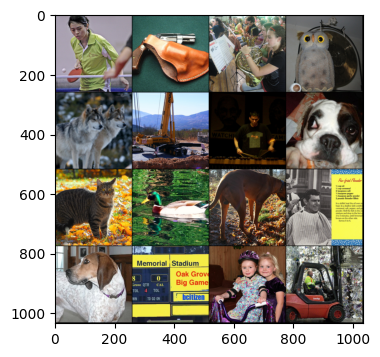

In [104]:
xt_vis = (gt.float() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

In [ ]:
def inverseSample(y, operator, num_stages, inference_each_step, ode_steps_per_stage, langevin_steps, 
                  Langevin_proj, resolution, device, return_traj = True, fix_stage_noise = False, renoise = False, 
                  guidance=0., lr_base = 1e-3,lr_min_ratio = 1e-2):
    from tqdm.auto import tqdm
    x0_hats_before_Langevin = []
    x0_hats_after_Langevin = []
    xts = []
    for stage_idx in range(num_stages):
        initial_factor = 2**(num_stages - 1)
        h,w = resolution//initial_factor, resolution//initial_factor

        if isinstance(inference_each_step, list):
            scheduler.set_timesteps(inference_each_step[stage_idx], stage_idx, device=device, shift=shift)
        else:
            scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps = scheduler.Timesteps
        if fix_stage_noise:  
            if stage_idx == 0:
                stage_noise = torch.randn(NUM_EXAMPLES, 3, h,w).float().to(device)
                x0_hat = y.detach().clone()
            else:
                stage_noise = get_stage_noise(stage_noise).to(device)
        else:
            if stage_idx == 0:
                x0_hat = y.detach().clone()
            stage_noise = None

        pbar = tqdm(Timesteps.float(), desc = f"Stage: {stage_idx}")
        for T in pbar:
            if renoise and stage_idx >0:
                xt = get_xt_from_x1(scheduler, Timesteps, x0_hat, stage_idx, T, stage_noise = stage_noise, last_stage_xt = xt, renoise = renoise)
                xts.append(xt.cpu().float().numpy())
            else:
                xt = get_xt_from_x1(scheduler, Timesteps, x0_hat, stage_idx, T, stage_noise = stage_noise)
                xts.append(xt.cpu().float().numpy())
            with torch.autocast("cuda", dtype=torch.bfloat16), torch.no_grad():
                x0_hat = sampler_pipeline(prompt=[class_label] * NUM_EXAMPLES,
                                                height=resolution,
                                                width=resolution,
                                                num_inference_steps=ode_steps_per_stage,
                                                guidance_scale=guidance,
                                                num_images_per_prompt=1,
                                                device=device,
                                                shift=shift,
                                                use_ode_dopri5=False,
                                                xt = xt,          
                                                start_stage = stage_idx,             
                                                start_T = T,
                                                noises = None,          
                                                normalized_x0_hat = False,
                                                verbose = False)
            # print(x0_hat.shape, T)
            x0_hats_before_Langevin.append(x0_hat.cpu().float().numpy())
            ratio = T/1000
            lr = get_lr(ratio, lr_base, lr_min_ratio)
            x0_hat_last = copy.deepcopy(x0_hat)
            x0_hat = langevin_sample(x0_hat_last, operator, y, x0_hat, sigma_n, T, step_size=lr, num_steps=10, device = device, proj = Langevin_proj)
            x0_hats_after_Langevin.append(x0_hat.cpu().float().numpy())

    if return_traj:
        return xts, x0_hats_before_Langevin, x0_hats_after_Langevin

In [92]:
# To-do
# Consider remove Langevin in the last step or last few steps

In [108]:
seed_everything(20000120)
langevin_steps = 50
ode_steps_per_stage = 10
inference_each_step = 10 #[10, 10, 10, 10]
lr_base = 1e-3
lr_min_ratio = 1e-3
torch.cuda.synchronize(device)
t0 = time.perf_counter()
xts, x0s_woL, x0s_L = inverseSample(y = y, 
                                    operator = A_opr, 
                                    num_stages = num_stages,
                                    inference_each_step = inference_each_step, 
                                    ode_steps_per_stage = ode_steps_per_stage, 
                                    langevin_steps = langevin_steps, 
                                    Langevin_proj = False, 
                                    resolution = 256, 
                                    device = device, 
                                    return_traj = True, 
                                    fix_stage_noise = False, 
                                    renoise = False,
                                    guidance = 0.0, 
                                    lr_base = lr_base,
                                    lr_min_ratio = lr_min_ratio)
torch.cuda.synchronize(device)
dt = time.perf_counter() - t0

Stage: 0:   0%|          | 0/10 [00:00<?, ?it/s]

Start T: 0.0


Stage: 0:  10%|█         | 1/10 [00:21<03:10, 21.12s/it]

Start T: 0.0


Stage: 0:  20%|██        | 2/10 [00:42<02:49, 21.17s/it]

...

Stage: 3:  80%|████████  | 8/10 [00:40<00:07,  3.75s/it]

Start T: 0.6000000000000001


Stage: 3:  90%|█████████ | 9/10 [00:41<00:03,  3.07s/it]

Start T: 0.6000000000000001


Stage: 3: 100%|██████████| 10/10 [00:42<00:00,  4.25s/it]


In [109]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# ===== 工具函数（你已有的，保留）=====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x
def normalize_for_display(img):
    samples = (img / 2 + 0.5).clip(0, 1)
    return samples
    # """
    # 更稳健：把 [-1,1] / [0,1] / [0,255] 都统一到 [0,1] 显示
    # """
    # img = img.astype(np.float32)
    # mn, mx = float(img.min()), float(img.max())
    # if mn < -0.05 and mx <= 1.05:
    #     img = img * 0.5 + 0.5
    #     return np.clip(img, 0, 1)
    # if mx > 1.5:
    #     return np.clip(img / 255.0, 0, 1)
    # return np.clip(img, 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    # x_img/y_img: HxW or HxWxC float
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


# =========================
# 1) 你的输入（按你变量名）
# =========================
traj_before = x0s_woL
traj_after  = x0s_L
traj_xt     = xts

traj_list  = [traj_before, traj_after, traj_xt]
row_names  = ["Before Langevin", "After Langevin", "xt", "GT"]

gt = gt

# 你要展示哪些 batch index（3列 or 4列都行）
# 例如：3列
plot_ids = [0, 3, 8, 12]
# 例如：4列就改成
# plot_ids = [0, 1, 2, 3]

def build_T_and_stage_list(num_stages,inference_each_step, shift, expected_len=None):
    T_list, stage_list = [], []
    for s in range(num_stages):
        if isinstance(inference_each_step, list):
            scheduler.set_timesteps(inference_each_step[s], s, shift=shift)
        else:
            scheduler.set_timesteps(inference_each_step, s, shift=shift)
        Timesteps = scheduler.Timesteps
        for T in Timesteps:
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L]
    return T_list, stage_list

T_list, stage_list = build_T_and_stage_list(num_stages, inference_each_step, shift, expected_len=len(xts))
T_list = T_list

# 显示策略
x_assume_image_range = True   # x0s_woL/x0s_L 如果已经是[0,1]图像就 True
gt_assume_image_range = True
xt_assume_image_range = False # xt 多半是噪声/latent，建议 False 用 min-max 显示（否则一片黑/白）

# 输出
save_dir = "./vis/IP"
os.makedirs(save_dir, exist_ok=True)
mp4_path = os.path.join(save_dir, f"WoProjx0s_nut_{inference_each_step}_step{ode_steps_per_stage}_L{langevin_steps}_Lbase{lr_base}_TimeCost{dt:.2f}s.mp4")
fps = 6


# =========================
# 2) 对齐帧数
# =========================
min_len = min(len(t) for t in traj_list)
min_len = min(min_len, len(T_list))
traj_list = [t[:min_len] for t in traj_list]
T_list = T_list[:min_len]


# =========================
# 3) 预处理 GT：每个 plot_id 一个 GT 图
# =========================
gt_imgs  = [to_display_image(gt, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im) for im in gt_imgs]


# =========================
# 4) 画图布局：rows=4, cols=len(plot_ids)
#    row0: Before
#    row1: After
#    row2: xt
#    row3: GT
# =========================
ncols = len(plot_ids)
nrows = 4

fig_w = 4.2 * ncols
fig_h = 9.5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

# 统一把 axes 变成 2D 数组
if ncols == 1:
    axes = axes.reshape(nrows, 1)

# 间距调小
plt.subplots_adjust(wspace=0.02, hspace=0.06, top=0.93)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        fig.suptitle(f"Frame {i} | T = {T_str}", fontsize=12)

        # 每一列 = 一个 plot_id
        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]  # 原始 GT（用于算 mse/mae）
            target_disp = gt_disps[c]

            # ===== Row0~Row2: 三条 traj =====
            for r in range(3):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)

                # 对 xt 单独用 min-max 更好看
                assume = x_assume_image_range if r < 2 else xt_assume_image_range
                x_disp = normalize_for_display(x_img)

                # 画图
                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                # mse/mae（在“原始 x_img vs 原始 target_img”上算）
                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}", fontsize=9)
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row3: GT =====
            ax = axes[3, c]
            ax.clear()
            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)
            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./vis/IP/WoProjx0s_nut_10_step10_L50_Lbase0.001_TimeCost621.20s.mp4


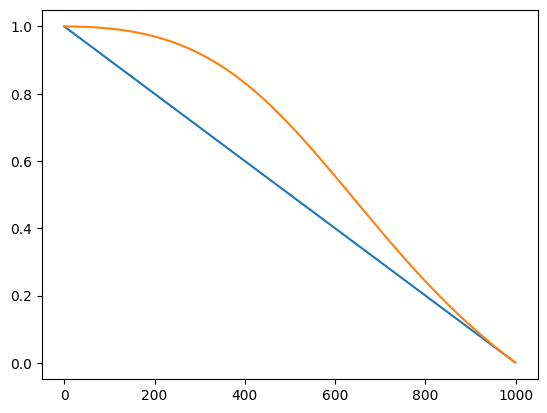

In [88]:
T = np.linspace(0, 999, 2000)
nt = T/1000
nt2 = (1 - nt)/np.sqrt(nt**2 + (1 - nt)**2)
plt.plot(T, 1-nt)
plt.plot(T, nt2, label = "nu")

In [79]:
nt**2 + (1 - nt)**2

array([1.      , 0.999001, 0.998003, ..., 0.996009, 0.997005, 0.998002],
      shape=(2000,))

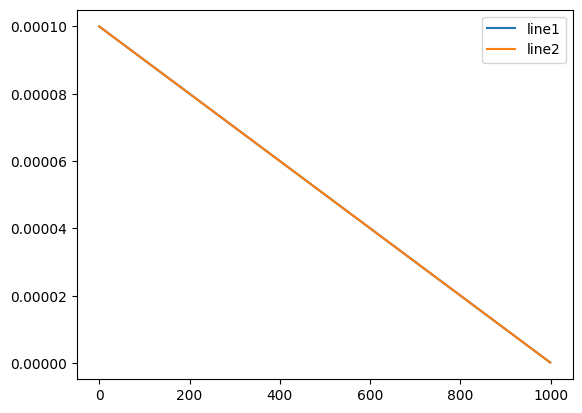

In [124]:
def get_lr2(ratio, lr_base = 1e-4, lr_min_ratio = 0.01):
    p = 1
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    # print(multiplier)
    return multiplier * lr_base

l = np.linspace(0, 999, 1000)
ratio = l/1000
lr1 = get_lr2(ratio, 1e-4, lr_min_ratio = 1e-3)
lr2 = get_lr2(ratio, 1e-3, lr_min_ratio = 10)
plt.plot(l, lr1, label = "line1")
plt.plot(l, lr1,  label = "line2")
# plt.plot(l, lr1 - lr2)
plt.legend()

In [128]:
lr1

array([1.00000e-04, 9.99001e-05, 9.98002e-05, 9.97003e-05, 9.96004e-05,
       9.95005e-05, 9.94006e-05, 9.93007e-05, 9.92008e-05, 9.91009e-05,
       9.90010e-05, 9.89011e-05, 9.88012e-05, 9.87013e-05, 9.86014e-05,
       9.85015e-05, 9.84016e-05, 9.83017e-05, 9.82018e-05, 9.81019e-05,
       9.80020e-05, 9.79021e-05, 9.78022e-05, 9.77023e-05, 9.76024e-05,
       9.75025e-05, 9.74026e-05, 9.73027e-05, 9.72028e-05, 9.71029e-05,
       9.70030e-05, 9.69031e-05, 9.68032e-05, 9.67033e-05, 9.66034e-05,
       9.65035e-05, 9.64036e-05, 9.63037e-05, 9.62038e-05, 9.61039e-05,
       9.60040e-05, 9.59041e-05, 9.58042e-05, 9.57043e-05, 9.56044e-05,
       9.55045e-05, 9.54046e-05, 9.53047e-05, 9.52048e-05, 9.51049e-05,
       9.50050e-05, 9.49051e-05, 9.48052e-05, 9.47053e-05, 9.46054e-05,
       9.45055e-05, 9.44056e-05, 9.43057e-05, 9.42058e-05, 9.41059e-05,
       9.40060e-05, 9.39061e-05, 9.38062e-05, 9.37063e-05, 9.36064e-05,
       9.35065e-05, 9.34066e-05, 9.33067e-05, 9.32068e-05, 9.310

In [129]:
lr2

array([0.001   , 0.001009, 0.001018, 0.001027, 0.001036, 0.001045,
       0.001054, 0.001063, 0.001072, 0.001081, 0.00109 , 0.001099,
       0.001108, 0.001117, 0.001126, 0.001135, 0.001144, 0.001153,
       0.001162, 0.001171, 0.00118 , 0.001189, 0.001198, 0.001207,
       0.001216, 0.001225, 0.001234, 0.001243, 0.001252, 0.001261,
       0.00127 , 0.001279, 0.001288, 0.001297, 0.001306, 0.001315,
       0.001324, 0.001333, 0.001342, 0.001351, 0.00136 , 0.001369,
       0.001378, 0.001387, 0.001396, 0.001405, 0.001414, 0.001423,
       0.001432, 0.001441, 0.00145 , 0.001459, 0.001468, 0.001477,
       0.001486, 0.001495, 0.001504, 0.001513, 0.001522, 0.001531,
       0.00154 , 0.001549, 0.001558, 0.001567, 0.001576, 0.001585,
       0.001594, 0.001603, 0.001612, 0.001621, 0.00163 , 0.001639,
       0.001648, 0.001657, 0.001666, 0.001675, 0.001684, 0.001693,
       0.001702, 0.001711, 0.00172 , 0.001729, 0.001738, 0.001747,
       0.001756, 0.001765, 0.001774, 0.001783, 0.001792, 0.001